# Assignment 4 Report 

Name: Tianna Calderon

Collaborators (if any - humans or not):

Asssistance with Deepseek - Get a better understanding of how MPI works/how to navigate tuckoo

References:

SLURM: https://slurm.schedmd.com/overview.html

MPI: https://www.mpi-forum.org/
https://juliaparallel.org/MPI.jl/stable/

MST: https://en.wikipedia.org/wiki/Minimum_spanning_tree
Binary Tree: https://en.wikipedia.org/wiki/Binary_tree



In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [55]:
# Open the CSV file for reading
header = ['MPI size:', 'buf (reduced sum):', 'Execution time:']


csv_mst = pd.read_csv('tuckoo_files/mstreduce_results.csv', delimiter=',')
csv_mst.columns = header


csv_naivereduce = pd.read_csv('tuckoo_files/naivereduce_results.csv', delimiter=',')
csv_naivereduce.columns = header

csv_nonmst = pd.read_csv('tuckoo_files/mstreducenon_results.csv', delimiter=',')
csv_nonmst.columns = header

csv_compare = pd.read_csv('tuckoo_files/reducecompare_results.csv', delimiter=',')
csv_compare.columns = ['MPI size:', 'Execution time (MST):', 'Execution time (NVE):']


In [57]:
print(f"MST  \n {csv_mst} \n")

print(f"Naive \n {csv_naivereduce} \n" )

print(f"Compare \n {csv_compare} \n" )

MST  
    MPI size:  buf (reduced sum):  Execution time:
0          4                  10         0.000057
1          6                  27         0.000084
2          8                  52         0.000084
3         10                  85         0.000218
4         12                 126         0.000422
5         14                 175         0.000253
6         16                 232         0.000132 

MST Non-recursive 
    MPI size:  buf (reduced sum):  Execution time:
0          4                  10         0.000057
1          6                  27         0.000084
2          8                  52         0.000084
3         10                  85         0.000218
4         12                 126         0.000422
5         14                 175         0.000253
6         16                 232         0.000132 

Naive 
    MPI size:  buf (reduced sum):  Execution time:
0          4                  10         0.000062
1          6                  27         0.000050
2          

Text(0.5, 1.0, 'MST vs NVE')

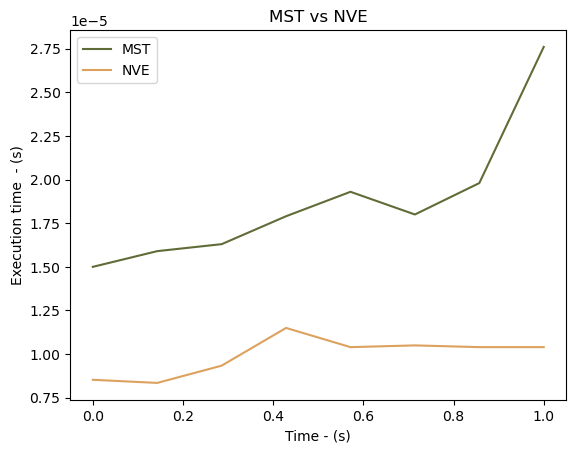

In [58]:
t = np.linspace(0, 1, num = 8)
x_mst = csv_mst['MPI size:']
y_mst = csv_mst['Execution time:']
compare_mst = csv_compare['Execution time (MST):']
compare_nve = csv_compare['Execution time (NVE):']


fig, ax = plt.subplots()


ax.plot(t,compare_mst, label = "MST", color = '#606c38')
ax.plot(t,compare_nve, label = "NVE", color = '#dda15e')
ax.set_ylabel('Execution time  - (s)')
ax.set_xlabel('Time - (s)')
ax.legend()
ax.set_title("MST vs NVE")

1) Analysis
       As we can see with the graph above, MST takes a much longer time than the naive algorithm. I think this may have been due to specialized functions like "similar()" it needs to create new temp buffer in order to accept new data. As we learned earlier in the class, memory allocation is important because of its high cost. Similar is a function that requires high memory allocation.
       Another thing that could of contributed to my version of MST taking longer is due to the amount of Send/Recv calls. It creates a lot of latency due to memory needed to be called.
       A combination of these factors, I believe is what causes my MST for reduce(to-one) to be slower. 

### Extra Credit
1) What are the total parallel costs (in terms of number of steps and cost per step) of the naive and MST reduce algorithms? For these, you want to use the same notation as in the references, i.e., α and β, respectively, represent the message startup time and per data item transmission time, γ denotes the cost required to perform an arithmetic operation (e.g. a reduction operation), and n is the length of the message.

   #### NAIVE:
       Number of Steps:
           The root (final value) is created to be in a loop to be sequential and recieving. The benefit of this is that other ranks can handle other processes, but the root must always be processing one thing at a time. This ends up creating a equation that is based on vector length, the number of processes that the root must handle, latency, per-word communication time or per-element addition time.

       Cost of step:
            Each step for a transmission of send/recieve involves cost of (α + βn)
            If its a vector addition : γn

           Time is defined as : =(p−1)(α+βn+γn)

       


   #### MST:
       Parallel steps
       Number of steps = log₂(p)

       How it works is by reducing the number of processeses acting in half.

       Communication Cost:O((α + βn) * log₂(p))

       Total Time: O(log₂ p (α + βn + γn))

   Example of output value:

       n = 8 p = 8 α = 1 β = 1 γ = 1

       Naive
           Cost for receiving:
           α + βn + γn = 1 + 8 + 8 = 17
           Cost on root:

               T = 7x17 = 119

           Paralle time = O(p) = 7

       MST
           Number of steps = log₂(p) = log₂(7) = 3

           Cost recieve/send (Same as Naive): 17 (but split since its parallel amongst 3 levels)
            Cost for root: 3x17 = 51
           
           
           
    
3) Compare Non-recursive with recursive MST

In [71]:
print(f"MST Non-recursive \n {csv_nonmst} \n")

MST Non-recursive 
    MPI size:  buf (reduced sum):  Execution time:
0          4                  10         0.000068
1          6                  27         0.000084
2          8                  52         0.000099 



Text(0.5, 1.0, 'MST vs NVE')

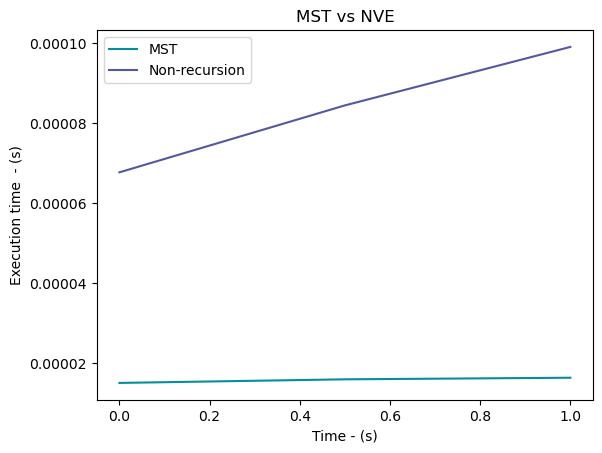

In [74]:
compare_nonrecursion = csv_nonmst['Execution time:']
t_1 = np.linspace(0, 1, num = 3)

fig, ax = plt.subplots()

ax.plot(t_1,compare_mst[:3], label = "MST", color = '#068D9D')
ax.plot(t_1, compare_nonrecursion, label = "Non-recursion", color = '#53599A')
ax.set_ylabel('Execution time  - (s)')
ax.set_xlabel('Time - (s)')
ax.legend()
ax.set_title("MST vs NVE")


As we can see MST is faster than the non-recursion version. This may due to the fact that the non-recursion takes a bit more time to process, as the recursion has recent memory it can allocate much faster to complete tasks.